In [1]:
import sys
!{sys.executable} -m pip install scikit-learn

In [2]:
import pandas as pd
import numpy as np
import pickle
import os
import warnings
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings('ignore')

DATA_DIR   = '../backend/data/'
MODELS_DIR = '../backend/models/'
os.makedirs(MODELS_DIR, exist_ok=True)

print('✅ Imports done!')

✅ Imports done!


## Load Cleaned Data

In [3]:
movies  = pd.read_csv(os.path.join(DATA_DIR, 'movies.csv'))
ratings = pd.read_csv(os.path.join(DATA_DIR, 'ratings.csv'))

print(f'Movies  : {movies.shape}')
print(f'Ratings : {ratings.shape}')
movies[['movie_id', 'title_clean', 'year', 'genres', 'rating_count', 'rating_mean']].head()

Movies  : (9742, 7)
Ratings : (100836, 4)


,movie_id,title_clean,year,genres,rating_count,rating_mean
0,1,Toy Story,1995.0,Adventure|Animation|Children|Comedy|Fantasy,215,3.92
1,2,Jumanji,1995.0,Adventure|Children|Fantasy,110,3.43
2,3,Grumpier Old Men,1995.0,Comedy|Romance,52,3.26
3,4,Waiting to Exhale,1995.0,Comedy|Drama|Romance,7,2.36
4,5,Father of the Bride Part II,1995.0,Comedy,49,3.07


## Feature Engineering


In [4]:

def year_to_decade_tag(year):
    if pd.isna(year):
        return ''
    decade = int(year // 10 * 10)
    return f'decade_{decade}s'

movies['decade_tag'] = movies['year'].apply(year_to_decade_tag)

def build_soup(row):
    genres_str  = row['genres'].replace('|', ' ') if pd.notna(row['genres']) else ''
    decade_str  = row['decade_tag']
    return f"{genres_str} {genres_str} {decade_str}"

movies['soup'] = movies.apply(build_soup, axis=1)

print('Sample soups:')
movies[['title_clean', 'genres', 'decade_tag', 'soup']].head(8)

Sample soups:


,title_clean,genres,decade_tag,soup
0,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,decade_1990s,Adventure Animation Children Comedy Fantasy Ad...
1,Jumanji,Adventure|Children|Fantasy,decade_1990s,Adventure Children Fantasy Adventure Children ...
2,Grumpier Old Men,Comedy|Romance,decade_1990s,Comedy Romance Comedy Romance decade_1990s
3,Waiting to Exhale,Comedy|Drama|Romance,decade_1990s,Comedy Drama Romance Comedy Drama Romance deca...
4,Father of the Bride Part II,Comedy,decade_1990s,Comedy Comedy decade_1990s
5,Heat,Action|Crime|Thriller,decade_1990s,Action Crime Thriller Action Crime Thriller de...
6,Sabrina,Comedy|Romance,decade_1990s,Comedy Romance Comedy Romance decade_1990s
7,Tom and Huck,Adventure|Children,decade_1990s,Adventure Children Adventure Children decade_1...


## TF-IDF Vectorization


In [5]:

tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(movies['soup'])

print(f'TF-IDF Matrix Shape: {tfidf_matrix.shape}')
print(f'  → {tfidf_matrix.shape[0]} movies × {tfidf_matrix.shape[1]} features')
print(f'\nFeature names (vocabulary):')
print(tfidf.get_feature_names_out())

TF-IDF Matrix Shape: (9742, 34)
  → 9742 movies × 34 features

Feature names (vocabulary):
['action' 'adventure' 'animation' 'children' 'comedy' 'crime'
 'decade_1900s' 'decade_1910s' 'decade_1920s' 'decade_1930s'
 'decade_1940s' 'decade_1950s' 'decade_1960s' 'decade_1970s'
 'decade_1980s' 'decade_1990s' 'decade_2000s' 'decade_2010s' 'documentary'
 'drama' 'fantasy' 'fi' 'film' 'horror' 'imax' 'musical' 'mystery' 'noir'
 'romance' 'sci' 'thriller' 'unknown' 'war' 'western']


In [6]:

sample_idx = 0
sample_movie = movies.iloc[sample_idx]
feature_names = tfidf.get_feature_names_out()
tfidf_scores = tfidf_matrix[sample_idx].toarray()[0]

tfidf_df = pd.DataFrame({
    'feature': feature_names,
    'tfidf_score': tfidf_scores
}).sort_values('tfidf_score', ascending=False)

print(f"TF-IDF vector for: '{sample_movie['title_clean']}'")
print(f"Genres: {sample_movie['genres']}")
tfidf_df[tfidf_df['tfidf_score'] > 0]

TF-IDF vector for: 'Toy Story'
Genres: Adventure|Animation|Children|Comedy|Fantasy


,feature,tfidf_score
2,animation,0.508919
3,children,0.497700
20,fantasy,0.476154
1,adventure,0.410946
4,comedy,0.263799
15,decade_1990s,0.167646


## Cosine Similarity Matrix


In [7]:
sim_matrix = cosine_similarity(tfidf_matrix, tfidf_matrix)

print(f'Similarity Matrix Shape: {sim_matrix.shape}')
print(f'\nSample values (movie 0 vs first 5 movies):')
print(sim_matrix[0][:5])
print(f'\nSelf-similarity (should always be 1.0): {sim_matrix[0][0]:.4f}')

Similarity Matrix Shape: (9742, 9742)

Sample values (movie 0 vs first 5 movies):
[1.         0.81939667 0.1987551  0.17808066 0.31256268]

Self-similarity (should always be 1.0): 1.0000


In [8]:
movie_index = pd.Series(movies.index, index=movies['title_clean']).drop_duplicates()

print(f'Movie index size: {len(movie_index)}')
print('\nSample entries:')
print(movie_index.head(5))

Movie index size: 9742

Sample entries:
title_clean
Toy Story                      0
Jumanji                        1
Grumpier Old Men               2
Waiting to Exhale              3
Father of the Bride Part II    4
dtype: int64


## The Recommendation Functions


In [9]:

def recommend_similar(title, n=10):
    if title not in movie_index:
        return f"Movie '{title}' not found in dataset."
    
    idx = movie_index[title]                      
    sim_scores = list(enumerate(sim_matrix[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:n+1]               
    
    movie_indices = [i[0] for i in sim_scores]
    scores        = [round(i[1], 4) for i in sim_scores]
    
    result = movies.iloc[movie_indices][['title_clean', 'genres', 'year', 'rating_mean', 'rating_count']].copy()
    result['similarity_score'] = scores
    return result.reset_index(drop=True)


print("=== Movies similar to 'Toy Story' ===")
recommend_similar('Toy Story', n=10)

=== Movies similar to 'Toy Story' ===


,title_clean,genres,year,rating_mean,rating_count,similarity_score
0,Antz,Adventure|Animation|Children|Comedy|Fantasy,1998.0,3.24,45,1.0000
1,Toy Story 2,Adventure|Animation|Children|Comedy|Fantasy,1999.0,3.86,97,1.0000
2,"Adventures of Rocky and Bullwinkle, The",Adventure|Animation|Children|Comedy|Fantasy,2000.0,2.22,9,0.9745
3,"Emperor's New Groove, The",Adventure|Animation|Children|Comedy|Fantasy,2000.0,3.72,37,0.9745
4,"Monsters, Inc.",Adventure|Animation|Children|Comedy|Fantasy,2001.0,3.87,132,0.9745
5,"Wild, The",Adventure|Animation|Children|Comedy|Fantasy,2006.0,2.50,1,0.9745
6,Shrek the Third,Adventure|Animation|Children|Comedy|Fantasy,2007.0,3.02,21,0.9745
7,"Tale of Despereaux, The",Adventure|Animation|Children|Comedy|Fantasy,2008.0,3.00,1,0.9745
8,Asterix and the Vikings (Astérix et les Vikings),Adventure|Animation|Children|Comedy|Fantasy,2006.0,5.00,1,0.9745
9,Turbo,Adventure|Animation|Children|Comedy|Fantasy,2013.0,2.50,1,0.9704


In [10]:

def recommend_from_preferences(genres=None, decade=None, n=10, min_ratings=20):
    
    query_parts = []
    
    if genres:
        genre_str = ' '.join(genres)
        query_parts.append(f"{genre_str} {genre_str}")  # repeat for weight
    
    if decade:
        query_parts.append(f"decade_{decade}s")
    
    if not query_parts:
        return "Please provide at least one genre or decade."
    
    query_soup = ' '.join(query_parts)
    
    query_vec = tfidf.transform([query_soup])
    
    query_sim = cosine_similarity(query_vec, tfidf_matrix).flatten()
    
  
    result = movies.copy()
    result['similarity_score'] = query_sim
    
    result = result[result['rating_count'] >= min_ratings]
    
    result = result.sort_values(
        ['similarity_score', 'rating_mean'],
        ascending=[False, False]
    ).head(n)
    
    return result[['title_clean', 'genres', 'year', 'rating_mean', 'rating_count', 'similarity_score']].reset_index(drop=True)


print("=== Recommendations for Action + Thriller fan (1990s) ===")
recommend_from_preferences(genres=['Action', 'Thriller'], decade=1990, n=10)

=== Recommendations for Action + Thriller fan (1990s) ===


,title_clean,genres,year,rating_mean,rating_count,similarity_score
0,In the Line of Fire,Action|Thriller,1993.0,3.69,70,1.000000
1,Enemy of the State,Action|Thriller,1998.0,3.49,67,1.000000
2,Payback,Action|Thriller,1999.0,3.42,45,1.000000
3,Air Force One,Action|Thriller,1997.0,3.34,58,1.000000
4,"River Wild, The",Action|Thriller,1994.0,3.25,40,1.000000
5,Drop Zone,Action|Thriller,1994.0,2.86,22,1.000000
6,Dante's Peak,Action|Thriller,1997.0,2.62,24,1.000000
7,Wanted,Action|Thriller,2008.0,3.16,22,0.910223
8,"Long Kiss Goodnight, The",Action|Drama|Thriller,1996.0,3.32,33,0.909843
9,Eraser,Action|Drama|Thriller,1996.0,3.11,64,0.909843


In [11]:

print("=== Comedy + Romance fan (1980s) ===")
recommend_from_preferences(genres=['Comedy', 'Romance'], decade=1980, n=8)

=== Comedy + Romance fan (1980s) ===


,title_clean,genres,year,rating_mean,rating_count,similarity_score
0,When Harry Met Sally...,Comedy|Romance,1989.0,3.86,85,1.000000
1,Better Off Dead...,Comedy|Romance,1985.0,3.69,27,1.000000
2,Sixteen Candles,Comedy|Romance,1984.0,3.60,49,1.000000
3,Moonstruck,Comedy|Romance,1987.0,3.56,27,1.000000
4,Coming to America,Comedy|Romance,1988.0,3.46,24,1.000000
5,Tootsie,Comedy|Romance,1982.0,3.42,32,1.000000
6,Say Anything...,Comedy|Drama|Romance,1989.0,3.92,39,0.901549
7,Bull Durham,Comedy|Drama|Romance,1988.0,3.67,35,0.901549


In [12]:
print("=== Horror fan (no decade preference) ===")
recommend_from_preferences(genres=['Horror'], n=8)

=== Horror fan (no decade preference) ===


,title_clean,genres,year,rating_mean,rating_count,similarity_score
0,"Shining, The",Horror,1980.0,4.08,109,0.904346
1,Halloween,Horror,1978.0,3.72,27,0.856898
2,Interview with the Vampire: The Vampire Chroni...,Drama|Horror,1994.0,3.46,109,0.833114
3,Shaun of the Dead,Comedy|Horror,2004.0,4.01,77,0.826211
4,Scary Movie,Comedy|Horror,2000.0,2.92,50,0.826211
5,Scary Movie 3,Comedy|Horror,2003.0,2.28,20,0.826211
6,Arachnophobia,Comedy|Horror,1990.0,2.81,53,0.818592
7,Gremlins,Comedy|Horror,1984.0,3.38,41,0.797217


In [13]:
print("=== Movies similar to 'Star Wars' ===")
recommend_similar('Star Wars', n=10)

=== Movies similar to 'Star Wars' ===


"Movie 'Star Wars' not found in dataset."

## Evaluate the Recommender


In [14]:

def evaluate_genre_overlap(input_genres, recommendations):

    input_set = set(g.lower() for g in input_genres)
    overlaps = []
    
    for _, row in recommendations.iterrows():
        movie_genres = set(row['genres'].lower().split('|'))
        overlap = len(input_set & movie_genres) / len(input_set)
        overlaps.append(overlap)
    
    recommendations = recommendations.copy()
    recommendations['genre_overlap'] = [round(o, 2) for o in overlaps]
    return recommendations



test_genres = ['Action', 'Thriller']
recs = recommend_from_preferences(genres=test_genres, decade=1990, n=10)
recs_evaluated = evaluate_genre_overlap(test_genres, recs)

print(f"=== Evaluation: Action + Thriller (1990s) ===")
print(f"Mean similarity score : {recs_evaluated['similarity_score'].mean():.4f}")
print(f"Mean genre overlap    : {recs_evaluated['genre_overlap'].mean():.2%}")
print()
recs_evaluated

=== Evaluation: Action + Thriller (1990s) ===
Mean similarity score : 0.9730
Mean genre overlap    : 100.00%



,title_clean,genres,year,rating_mean,rating_count,similarity_score,genre_overlap
0,In the Line of Fire,Action|Thriller,1993.0,3.69,70,1.000000,1.0
1,Enemy of the State,Action|Thriller,1998.0,3.49,67,1.000000,1.0
2,Payback,Action|Thriller,1999.0,3.42,45,1.000000,1.0
3,Air Force One,Action|Thriller,1997.0,3.34,58,1.000000,1.0
4,"River Wild, The",Action|Thriller,1994.0,3.25,40,1.000000,1.0
5,Drop Zone,Action|Thriller,1994.0,2.86,22,1.000000,1.0
6,Dante's Peak,Action|Thriller,1997.0,2.62,24,1.000000,1.0
7,Wanted,Action|Thriller,2008.0,3.16,22,0.910223,1.0
8,"Long Kiss Goodnight, The",Action|Drama|Thriller,1996.0,3.32,33,0.909843,1.0
9,Eraser,Action|Drama|Thriller,1996.0,3.11,64,0.909843,1.0


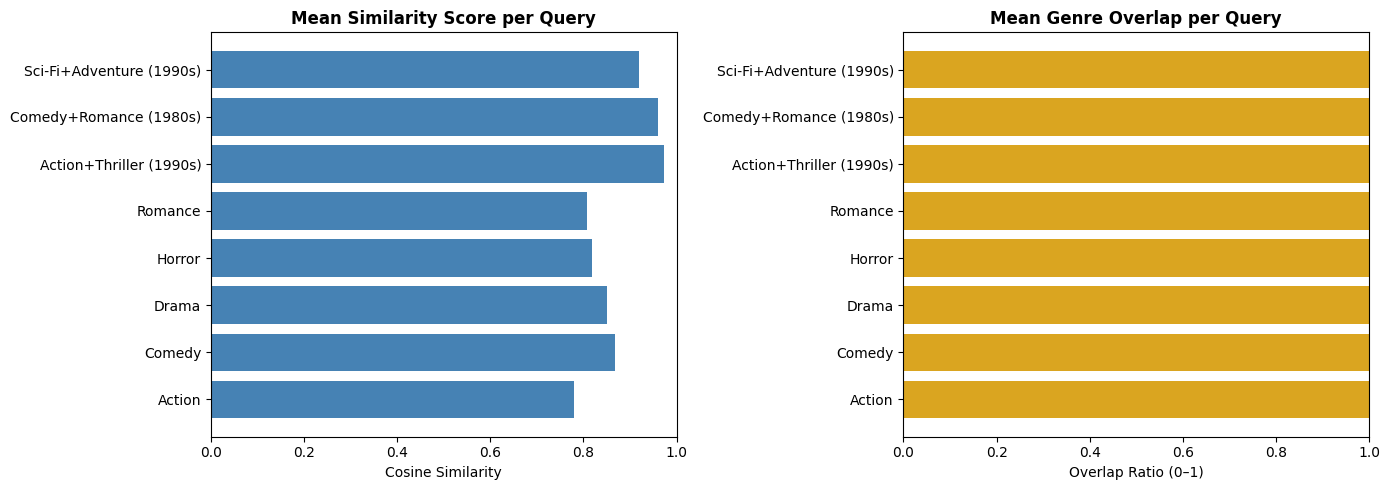

,query,mean_similarity,mean_genre_overlap
0,Action,0.780535,1.0
1,Comedy,0.868500,1.0
2,Drama,0.850668,1.0
3,Horror,0.817669,1.0
4,Romance,0.807868,1.0
5,Action+Thriller (1990s),0.972991,1.0
6,Comedy+Romance (1980s),0.960620,1.0
7,Sci-Fi+Adventure (1990s),0.919896,1.0


In [15]:

import matplotlib.pyplot as plt
import seaborn as sns

test_cases = [
    {'genres': ['Action'], 'decade': None},
    {'genres': ['Comedy'], 'decade': None},
    {'genres': ['Drama'], 'decade': None},
    {'genres': ['Horror'], 'decade': None},
    {'genres': ['Romance'], 'decade': None},
    {'genres': ['Action', 'Thriller'], 'decade': 1990},
    {'genres': ['Comedy', 'Romance'], 'decade': 1980},
    {'genres': ['Sci-Fi', 'Adventure'], 'decade': 1990},
]

eval_results = []
for tc in test_cases:
    recs = recommend_from_preferences(genres=tc['genres'], decade=tc['decade'], n=10)
    evaluated = evaluate_genre_overlap(tc['genres'], recs)
    label = '+'.join(tc['genres']) + (f" ({tc['decade']}s)" if tc['decade'] else '')
    eval_results.append({
        'query': label,
        'mean_similarity': evaluated['similarity_score'].mean(),
        'mean_genre_overlap': evaluated['genre_overlap'].mean()
    })

eval_df = pd.DataFrame(eval_results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(eval_df['query'], eval_df['mean_similarity'], color='steelblue')
axes[0].set_title('Mean Similarity Score per Query', fontweight='bold')
axes[0].set_xlabel('Cosine Similarity')
axes[0].set_xlim(0, 1)

axes[1].barh(eval_df['query'], eval_df['mean_genre_overlap'], color='goldenrod')
axes[1].set_title('Mean Genre Overlap per Query', fontweight='bold')
axes[1].set_xlabel('Overlap Ratio (0–1)')
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'content_based_eval.png'), bbox_inches='tight')
plt.show()

eval_df

## Save Models

In [16]:

with open(os.path.join(MODELS_DIR, 'similarity_matrix.pkl'), 'wb') as f:
    pickle.dump(sim_matrix, f)
print('✅ Saved: similarity_matrix.pkl')


with open(os.path.join(MODELS_DIR, 'tfidf_vectorizer.pkl'), 'wb') as f:
    pickle.dump(tfidf, f)
print('✅ Saved: tfidf_vectorizer.pkl')


with open(os.path.join(MODELS_DIR, 'movies_processed.pkl'), 'wb') as f:
    pickle.dump(movies, f)
print('✅ Saved: movies_processed.pkl')


with open(os.path.join(MODELS_DIR, 'movie_index.pkl'), 'wb') as f:
    pickle.dump(movie_index, f)
print('✅ Saved: movie_index.pkl')

print(f'\nAll model artifacts saved to: {MODELS_DIR}')

✅ Saved: similarity_matrix.pkl
✅ Saved: tfidf_vectorizer.pkl
✅ Saved: movies_processed.pkl
✅ Saved: movie_index.pkl

All model artifacts saved to: ../backend/models/


In [17]:

import os
print('Files in models/ directory:')
for f in os.listdir(MODELS_DIR):
    size_kb = os.path.getsize(os.path.join(MODELS_DIR, f)) / 1024
    print(f'  {f:40s} {size_kb:.1f} KB')

Files in models/ directory:
  cluster_labels.pkl                       0.2 KB
  kmeans_spotify.pkl                       351.6 KB
  movies_processed.pkl                     1464.0 KB
  movie_index.pkl                          329.3 KB
  predicted_ratings.pkl                    46422.3 KB
  similarity_matrix.pkl                    741457.7 KB
  spotify_pca.pkl                          1.0 KB
  spotify_scaler.pkl                       0.8 KB
  svd_model.pkl                            46457.7 KB
  tfidf_vectorizer.pkl                     1.4 KB
